### Load libraries

In [1]:
from pybaseball import statcast

import pandas as pd
import numpy as np
import polars as pl

import warnings
warnings.filterwarnings("ignore")

import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

import optuna
optuna.logging.set_verbosity(optuna.logging.INFO)

import requests

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# collect Statcast data
# documentation: https://baseballsavant.mlb.com/csv-docs
start_date = '2020-03-01'
end_date = '2025-10-31'

raw_data = statcast(start_date, end_date)
print(raw_data.shape)

This is a large query, it may take a moment to complete


  0%|                                                                                 | 1/1312 [00:00<04:06,  5.32it/s]

Skipping offseason dates
Skipping offseason dates
Skipping offseason dates
Skipping offseason dates
Skipping offseason dates
Skipping offseason dates


100%|██████████████████████████████████████████████████████████████████████████████| 1312/1312 [08:10<00:00,  2.68it/s]


(4126175, 118)


In [3]:
df = raw_data.copy().reset_index(drop=True)
# re-format names to readable format
split_names = df["player_name"].fillna("").str.split(",", n=1)
df["PlayerName"] = np.where(
    split_names.str.len() == 2,
    split_names.str[1].str.strip() + " " + split_names.str[0].str.strip(),
    df["player_name"]
)

In [4]:
## Define a dictionary to group outcomes together for expected run values
des_dict = {'ball':'ball',
'hit_into_play':'hit_into_play',
'called_strike':'called_strike',
'foul':'foul',
'swinging_strike':'swinging_strike',
'blocked_ball':'ball',
'swinging_strike_blocked':'swinging_strike',
'foul_tip':'swinging_strike',
'foul_bunt':'foul',
'hit_by_pitch':'hit_by_pitch',
'pitchout':'ball',
'missed_bunt':'swinging_strike',
'bunt_foul_tip':'swinging_strike',
'foul_pitchout':'foul',}

## Define a dictionary to group events together for expected run values
ev_dict = {'game_advisory':np.nan,
 'single':'single',
 'walk':'walk',
 np.nan:np.nan,
 'strikeout':'strikeout',
 'field_out':'field_out',
 'force_out':'field_out',
 'double':'double',
 'hit_by_pitch':'hit_by_pitch',
 'home_run':'home_run',
 'grounded_into_double_play':'field_out',
 'fielders_choice_out':'field_out',
 'fielders_choice':'field_out',
 'field_error':np.nan,
 'double_play':'field_out',
 'sac_fly':'field_out',
 'strikeout_double_play':np.nan,
 'triple':'triple',
 'caught_stealing_2b':np.nan,
 'sac_bunt':'field_out',
 'catcher_interf':np.nan,
 'caught_stealing_3b':np.nan,
 'sac_fly_double_play':'field_out',
 'triple_play':'field_out',
 'other_out':'field_out',
 'pickoff_3b':np.nan,
 'caught_stealing_home':np.nan,
 'pickoff_1b':np.nan,
 'pickoff_2b':np.nan,
 'wild_pitch':'wild_pitch',
 'stolen_base_2b':np.nan,
 'pickoff_caught_stealing_3b':np.nan,
 'pickoff_caught_stealing_2b':np.nan,
 'sac_bunt_double_play':np.nan,
 'passed_ball':np.nan,
 'pickoff_caught_stealing_home':np.nan,}

In [5]:
## Define lists which contain Swing Outcomes
swing_in = ['foul_bunt','foul','hit_into_play','swinging_strike', 'foul_tip', 'swinging_strike_blocked','missed_bunt','bunt_foul_tip']

In [6]:
# Define a function which applies relevant transformations
# Code derived from Thomas Nestico

def clean_for_xrv(df, val_year):
    df = df[(df.balls != 4) & (df.strikes != 3)].copy()

    df["des_new"] = df["description"].map(des_dict)
    df["des_new"] = np.where((df["des_new"] == "ball") & (df["balls"] == 3), "walk", df["des_new"])
    df["des_new"] = np.where(
        (df["des_new"].isin(["called_strike", "swinging_strike"])) & (df["strikes"] == 2),
        "strikeout",
        df["des_new"],
    )
    df["ev_new"] = df.loc[df["des_new"] == "hit_into_play", "events"].map(ev_dict)
    df.loc[df["des_new"] == "hit_into_play", "des_new"] = df.loc[df["des_new"] == "hit_into_play", "ev_new"]
    df = df.dropna(subset=["des_new"])

    train_mask = (df["game_year"].to_numpy() < val_year)

    des_values = (
        df.loc[train_mask]
          .groupby(["des_new", "strikes", "balls"])["delta_run_exp"]
          .mean()
          .reset_index(name="delta_run_exp_mean")
    )

    df = df.merge(des_values, on=["des_new", "strikes", "balls"], how="left")

    global_mean = df.loc[train_mask, "delta_run_exp"].mean()
    df["delta_run_exp_mean"] = df["delta_run_exp_mean"].fillna(global_mean)

    return df.dropna(subset=["pitch_type"])

In [7]:
def add_primary_pitch_deltas(
    df,
    primary_choices=("FF", "SI", "FC"),
    *,
    pitcher_col="pitcher",
    year_col="game_year",
    pitch_type_col="pitch_type",
    speed_col="release_speed",
    pfx_x_col="pfx_x",
    pfx_z_col="pfx_z",
):
    """
    Adds primary pitch baseline per pitcher-season and deltas vs that baseline.

    Primary pitch definition:
      - among `primary_choices`, pick the most-used pitch type for a given pitcher-season
      - tiebreaker: higher avg speed

    Fallback if pitcher-season throws none of `primary_choices`:
      - use fastest pitch (by avg speed) for that pitcher-season

    Returns a pandas DataFrame with:
      - avg_primary_speed, avg_primary_pfx_x, avg_primary_pfx_z
      - primary_delta_release_speed, primary_delta_pfx_x, primary_delta_pfx_z
    """

    pdf = df.copy()
    pl_df = pl.from_pandas(pdf)

    group_keys = [pitcher_col, year_col, pitch_type_col]

    # aggregate pitch-type means and counts per pitcher-season
    agg = (
        pl_df.group_by(group_keys)
        .agg(
            pl.len().alias("pt_count"),
            pl.col(speed_col).mean().alias("pt_avg_speed"),
            pl.col(pfx_z_col).mean().alias("pt_avg_pfx_z"),
            pl.col(pfx_x_col).mean().alias("pt_avg_pfx_x"),
        )
    )

    # candidate primary among chosen pitch types
    primary_candidates = (
        agg.filter(pl.col(pitch_type_col).is_in(list(primary_choices)))
        .sort(
            by=[pitcher_col, year_col, "pt_count", "pt_avg_speed"],
            descending=[False, False, True, True],
        )
        .unique(subset=[pitcher_col, year_col], keep="first")
        .select(
            pitcher_col,
            year_col,
            pl.col("pt_avg_speed").alias("avg_primary_speed"),
            pl.col("pt_avg_pfx_z").alias("avg_primary_pfx_z"),
            pl.col("pt_avg_pfx_x").alias("avg_primary_pfx_x"),
        )
    )

    # fallback: fastest pitch type for that pitcher-season (if no primary_choices)
    fastest_fallback = (
        agg.sort(
            by=[pitcher_col, year_col, "pt_avg_speed"],
            descending=[False, False, True],
        )
        .unique(subset=[pitcher_col, year_col], keep="first")
        .select(
            pitcher_col,
            year_col,
            pl.col("pt_avg_speed").alias("fb_primary_speed"),
            pl.col("pt_avg_pfx_z").alias("fb_primary_pfx_z"),
            pl.col("pt_avg_pfx_x").alias("fb_primary_pfx_x"),
        )
    )

    # join both baselines to every pitch row
    pl_df = (
        pl_df.join(primary_candidates, on=[pitcher_col, year_col], how="left")
             .join(fastest_fallback, on=[pitcher_col, year_col], how="left")
             .with_columns(
                 pl.when(pl.col("avg_primary_speed").is_null())
                   .then(pl.col("fb_primary_speed"))
                   .otherwise(pl.col("avg_primary_speed"))
                   .alias("avg_primary_speed"),
                 pl.when(pl.col("avg_primary_pfx_z").is_null())
                   .then(pl.col("fb_primary_pfx_z"))
                   .otherwise(pl.col("avg_primary_pfx_z"))
                   .alias("avg_primary_pfx_z"),
                 pl.when(pl.col("avg_primary_pfx_x").is_null())
                   .then(pl.col("fb_primary_pfx_x"))
                   .otherwise(pl.col("avg_primary_pfx_x"))
                   .alias("avg_primary_pfx_x"),
             )
             .drop(["fb_primary_speed", "fb_primary_pfx_z", "fb_primary_pfx_x"])
    )

    # deltas vs baseline
    pl_df = pl_df.with_columns(
        (pl.col(speed_col) - pl.col("avg_primary_speed")).alias("primary_delta_release_speed"),
        (pl.col(pfx_z_col) - pl.col("avg_primary_pfx_z")).alias("primary_delta_pfx_z"),
        (pl.col(pfx_x_col) - pl.col("avg_primary_pfx_x")).alias("primary_delta_pfx_x"),
    )

    pl_df = pl_df.with_columns(pl.col(year_col).cast(pl.Int64))

    return pl_df.to_pandas()

In [8]:
def clean_data(df, val_year):
    
    df = df[df.game_type == 'R'].copy()  # regular season only
    df = df[df.release_extension > 0]    # needed for log_extension

    # required columns
    must_have_cols = [
        'p_throws', 'pfx_x', 'pfx_z', 'release_speed', 'spin_axis',
        'release_spin_rate', 'release_extension',
        'release_pos_x', 'release_pos_z', 'arm_angle', 'p_throws'
    ]
    df = df.dropna(subset=must_have_cols)

    # remove unidentified pitches
    df = df[df.pitch_name != 'Other']

    # remove bunts
    bunt_plays = ['bunt_foul_tip', 'foul_bunt', 'missed_bunt']
    df = df[~df.description.isin(bunt_plays)]

    # remove clearly bad extensions
    df = df[df.release_extension <= 10]

    # rename batter stance
    df = df.rename(columns={'stand': 'batter_handedness'})

    # drop deprecated columns
    deprecated_columns = [c for c in df.columns if 'deprecated' in c]
    df = df.drop(columns=deprecated_columns)

    # filter rare pitch types globally
    vc = df['pitch_type'].value_counts()
    included_pitches = vc[vc >= 5000].index
    df = df[df.pitch_type.isin(included_pitches)]

    # Handedness features
    # explicit pitcher handedness feature
    df['is_lefty'] = (df['p_throws'] == 'L').astype(int)

    # convert movement to inches
    df['pfx_x'] = df['pfx_x'] * 12.0
    df['pfx_z'] = df['pfx_z'] * 12.0

    # Spin efficiency proxy
    eps = 1e-9
    train_mask = df['game_year'] < val_year  # avoid leakage

    df['total_movement'] = np.sqrt(df['pfx_x']**2 + df['pfx_z']**2)
    df['spin_efficiency_raw'] = (
        df['total_movement'] * df['release_speed']
        / (df['release_spin_rate'] + eps)
    )

    q95 = (
        df.loc[train_mask]
          .groupby('pitch_type')['spin_efficiency_raw']
          .quantile(0.95)
    )

    df['spin_eff_q95'] = df['pitch_type'].map(q95)
    df['spin_eff_q95'] = df['spin_eff_q95'].fillna(
        df.loc[train_mask, 'spin_efficiency_raw'].quantile(0.95)
    )

    df['spin_efficiency'] = (
        df['spin_efficiency_raw'] / (df['spin_eff_q95'] + eps)
    ).clip(0, 1.2)

    df = df.drop(columns=['spin_eff_q95'])

    # Spin axis
    df['spin_axis'] = pd.to_numeric(df['spin_axis'], errors='coerce')
    df = df.dropna(subset=['spin_axis'])

    df['spin_axis_rad'] = np.deg2rad(df['spin_axis'])
    df['spin_axis_x'] = np.cos(df['spin_axis_rad'])
    df['spin_axis_y'] = np.sin(df['spin_axis_rad'])

    # Log extension
    df['log_extension'] = np.log(df['release_extension'])

    # Pitch usage filtering
    counts = df.groupby(['pitcher', 'game_year', 'pitch_type']).size().rename('count')
    totals = df.groupby(['pitcher', 'game_year']).size().rename('total')

    pitch_frequencies = (
        counts.to_frame()
              .join(totals, on=['pitcher', 'game_year'])
    )
    pitch_frequencies['usage'] = pitch_frequencies['count'] / pitch_frequencies['total']
    pitch_frequencies = pitch_frequencies.reset_index()

    pitch_frequencies = pitch_frequencies[
        (pitch_frequencies['count'] >= 10) &
        (pitch_frequencies['usage'] > 0.01)
    ]

    df = df.merge(
        pitch_frequencies[['pitcher', 'game_year', 'pitch_type']],
        on=['pitcher', 'game_year', 'pitch_type'],
        how='inner'
    )

    return df, pitch_frequencies

In [9]:
year_col = "game_year"
pitch_type_col = "pitch_type"
target = "delta_run_exp_mean"

all_years = sorted(df[year_col].dropna().astype(int).unique())
if len(all_years) < 3:
    raise ValueError(f"Need >=3 distinct years for train/tune/report. Found: {all_years}")

report_year = int(all_years[-1])
val_year    = int(all_years[-2])          # tune / early-stop year
train_years = [int(y) for y in all_years[:-2]]

print(f"Train years: {train_years}")
print(f"Tune year:   {val_year}")
print(f"Report year: {report_year}")

Train years: [2020, 2021, 2022, 2023]
Tune year:   2024
Report year: 2025


In [10]:
df = clean_for_xrv(df, val_year)

In [11]:
# Clean + engineer features
primary_choices = ['FF', 'SI', 'FC']
df, pitch_frequencies = clean_data(df, val_year)
df = add_primary_pitch_deltas(df, primary_choices=primary_choices)

In [12]:
numeric_features = [
    'pfx_x','pfx_z','release_speed','release_spin_rate','release_extension',
    'release_pos_x','release_pos_z', 'spin_axis_x', 'spin_axis_y', 'spin_efficiency',
    'primary_delta_release_speed','primary_delta_pfx_x','primary_delta_pfx_z', 'is_lefty'
]

categorical_features = [pitch_type_col]

model_features = numeric_features + categorical_features

ID_COLS = ["pitcher", "PlayerName"]
df_current = df[ID_COLS + [year_col] + model_features + [target]].copy()

In [13]:
def tune_refit_predict(
    df_all,
    tune_year,
    report_year,
    train_years,
    *,
    year_col="game_year",
    pitch_type_col="pitch_type",
    target_col=target,
    model_features=model_features,
    n_trials=50,
):

    n_estimators_max = 5000
    early_stopping_rounds = 100
    seed = 162

    # 1) Tune on tune_year
    df_train = df_all[df_all[year_col].isin(train_years)].copy()
    df_tune  = df_all[df_all[year_col] == tune_year].copy()

    X_train = df_train[model_features].copy()
    y_train = df_train[target_col]
    X_tune  = df_tune[model_features].copy()
    y_tune  = df_tune[target_col]

    X_train[pitch_type_col] = X_train[pitch_type_col].astype("category")
    X_tune[pitch_type_col]  = X_tune[pitch_type_col].astype("category")

    def objective(trial):
        params = {
            "random_state": seed,
            "metric": "rmse",
            "n_estimators": n_estimators_max,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.10, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "num_leaves": trial.suggest_int("num_leaves", 16, 256),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 200, log=True),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "force_row_wise": True,
            "verbosity": -1,
        }

        model = LGBMRegressor(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_tune, y_tune)],
            eval_metric="rmse",
            categorical_feature=[pitch_type_col],
            callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False)],
        )
        preds = model.predict(X_tune)
        return mean_squared_error(y_tune, preds, squared=False)

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    # capture best params
    best_params = study.best_params.copy()
    best_params.update({
        "random_state": seed,
        "metric": "rmse",
        "force_row_wise": True,
        "verbosity": -1,
    })

    # fit a probe model once more to get best_iteration_
    probe_params = best_params.copy()
    probe_params["n_estimators"] = n_estimators_max

    probe = LGBMRegressor(**probe_params)
    probe.fit(
        X_train, y_train,
        eval_set=[(X_tune, y_tune)],
        eval_metric="rmse",
        categorical_feature=[pitch_type_col],
        callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False)],
    )
    best_n_estimators = int(getattr(probe, "best_iteration_", None) or n_estimators_max)
    best_params["n_estimators"] = best_n_estimators

    # 2) Refit on (train_years + tune_year), params fixed
    refit_years = list(train_years) + [tune_year]
    df_refit = df_all[df_all[year_col].isin(refit_years)].copy()
    X_refit  = df_refit[model_features].copy()
    y_refit  = df_refit[target_col]

    X_refit[pitch_type_col] = X_refit[pitch_type_col].astype("category")

    final_model = LGBMRegressor(**best_params)
    final_model.fit(
        X_refit, y_refit,
        categorical_feature=[pitch_type_col],
    )

    # 3) Predict/report on report_year
    df_report = df_all[df_all[year_col] == report_year].copy()
    X_report  = df_report[model_features].copy()
    X_report[pitch_type_col] = X_report[pitch_type_col].astype("category")

    df_report["pred_target_oos"] = final_model.predict(X_report)

    return final_model, study, df_report, best_n_estimators

In [14]:
model, study, df_report_pred, best_n = tune_refit_predict(
    df_current,
    tune_year=val_year,
    report_year=report_year,
    train_years=tuple(train_years),
    n_trials=50,
)

print("\nBest tune RMSE:", study.best_value)
print("Best params:", study.best_params)
print("Chosen n_estimators:", best_n)

[I 2026-02-11 01:21:45,028] A new study created in memory with name: no-name-5060c181-f4fb-4588-83fa-cb97ad3334f0
[I 2026-02-11 01:22:04,466] Trial 0 finished with value: 0.21638041911736217 and parameters: {'learning_rate': 0.01811619872635624, 'max_depth': 5, 'num_leaves': 217, 'min_child_samples': 10, 'subsample': 0.792099241121764, 'colsample_bytree': 0.5165338372122942, 'reg_alpha': 0.0015294674551145676, 'reg_lambda': 0.10094410589231861}. Best is trial 0 with value: 0.21638041911736217.
[I 2026-02-11 01:22:21,725] Trial 1 finished with value: 0.21638347311280381 and parameters: {'learning_rate': 0.05339753989436788, 'max_depth': 3, 'num_leaves': 245, 'min_child_samples': 27, 'subsample': 0.8914064410544247, 'colsample_bytree': 0.8763745964741961, 'reg_alpha': 0.010661311560341216, 'reg_lambda': 0.7835410307494287}. Best is trial 0 with value: 0.21638041911736217.
[I 2026-02-11 01:22:42,495] Trial 2 finished with value: 0.21638121561787263 and parameters: {'learning_rate': 0.0467

[I 2026-02-11 01:29:22,763] Trial 21 finished with value: 0.21637808349215407 and parameters: {'learning_rate': 0.028471658914818305, 'max_depth': 8, 'num_leaves': 110, 'min_child_samples': 200, 'subsample': 0.6815040976876507, 'colsample_bytree': 0.821162378886548, 'reg_alpha': 0.4936266208453285, 'reg_lambda': 0.013009349701318382}. Best is trial 17 with value: 0.21637285152023866.
[I 2026-02-11 01:29:33,483] Trial 22 finished with value: 0.21637521993356296 and parameters: {'learning_rate': 0.03360280736181767, 'max_depth': 7, 'num_leaves': 83, 'min_child_samples': 192, 'subsample': 0.5726484909094892, 'colsample_bytree': 0.8541356612476745, 'reg_alpha': 1.3596962428022947, 'reg_lambda': 0.010893732092762717}. Best is trial 17 with value: 0.21637285152023866.
[I 2026-02-11 01:29:51,958] Trial 23 finished with value: 0.21637459286614216 and parameters: {'learning_rate': 0.013426040991069827, 'max_depth': 8, 'num_leaves': 124, 'min_child_samples': 78, 'subsample': 0.7328828918850923, 

[I 2026-02-11 01:35:14,277] Trial 42 finished with value: 0.21637126275506274 and parameters: {'learning_rate': 0.01604681699744269, 'max_depth': 6, 'num_leaves': 22, 'min_child_samples': 41, 'subsample': 0.8068773946211365, 'colsample_bytree': 0.5401079749290785, 'reg_alpha': 5.644084074671787, 'reg_lambda': 0.0018761075964648895}. Best is trial 42 with value: 0.21637126275506274.
[I 2026-02-11 01:35:47,549] Trial 43 finished with value: 0.2163730038947524 and parameters: {'learning_rate': 0.015757465270533896, 'max_depth': 6, 'num_leaves': 20, 'min_child_samples': 37, 'subsample': 0.9326800709724616, 'colsample_bytree': 0.5339854761808681, 'reg_alpha': 5.48638351852765, 'reg_lambda': 0.0020843082871981828}. Best is trial 42 with value: 0.21637126275506274.
[I 2026-02-11 01:36:33,055] Trial 44 finished with value: 0.21637281119956706 and parameters: {'learning_rate': 0.01549596588372241, 'max_depth': 5, 'num_leaves': 16, 'min_child_samples': 37, 'subsample': 0.9039678917956306, 'colsa


Best tune RMSE: 0.21637126275506274
Best params: {'learning_rate': 0.01604681699744269, 'max_depth': 6, 'num_leaves': 22, 'min_child_samples': 41, 'subsample': 0.8068773946211365, 'colsample_bytree': 0.5401079749290785, 'reg_alpha': 5.644084074671787, 'reg_lambda': 0.0018761075964648895}
Chosen n_estimators: 1058


In [15]:
stuff_sd = 10
eps = 1e-9

d = df_report_pred.copy()

# 1) Global Stuff+
mu_g = d["pred_target_oos"].mean()
sd_g = d["pred_target_oos"].std(ddof=0)
z_g = (d["pred_target_oos"] - mu_g) / (sd_g + eps)

# Lower run value = better → higher Stuff+
d["Stuff+_global"] = 100 - stuff_sd * z_g

# 2) Pitch-type Stuff+
pt_mu = d.groupby(pitch_type_col)["pred_target_oos"].transform("mean")
pt_sd = d.groupby(pitch_type_col)["pred_target_oos"].transform(lambda s: s.std(ddof=0))
z_pt = (d["pred_target_oos"] - pt_mu) / (pt_sd + eps)

d["Stuff+_pt"] = 100 - stuff_sd * z_pt

df_scored = d

In [16]:
arsenal = (
    df_scored.groupby(["pitcher", "game_year", "pitch_type"])
      .size()
      .rename("count")
      .reset_index()
)

totals = df_scored.groupby(["pitcher", "game_year"]).size().rename("total").reset_index()

arsenal = arsenal.merge(totals, on=["pitcher", "game_year"])
arsenal["usage"] = arsenal["count"] / arsenal["total"]

# Define a pitch to be part of a pitcher's arsenal if it is thrown 3% of the time and at least 100 times overall
min_frequency = 0.03
min_count = 100
arsenal["is_arsenal"] = (arsenal["count"] >= min_count) & (arsenal["usage"] >= min_frequency)

df_scored = df_scored.merge(
    arsenal[["pitcher", "game_year", "pitch_type", "is_arsenal"]],
    on=["pitcher", "game_year", "pitch_type"],
    how="left"
)

In [17]:
player_pitch = (
    df_scored[df_scored['is_arsenal']]
    .groupby(["pitcher", pitch_type_col])
    .agg(
        n_pitches=("pred_target_oos", "size"),
        StuffPlus_pt=("Stuff+_pt", "mean"),
        StuffPlus_global=("Stuff+_global", "mean"),
    )
    .reset_index()
)

pitcher_overall = (
    df_scored[df_scored['is_arsenal']]
    .groupby(["pitcher"])
    .agg(
        n_pitches=("pred_target_oos", "size"),
        StuffPlus_pt=("Stuff+_pt", "mean"),
        StuffPlus_global=("Stuff+_global", "mean"),
    )
    .reset_index()
)

In [18]:
# Wide tables: one row per pitcher, pitch types as columns
wide_pt = player_pitch.pivot(index="pitcher", columns=pitch_type_col, values="StuffPlus_pt")
wide_global = player_pitch.pivot(index="pitcher", columns=pitch_type_col, values="StuffPlus_global")

# Combine into one table with suffixes
wide = (
    wide_pt.add_suffix("_pt")
    .join(wide_global.add_suffix("_global"), how="outer")
    .reset_index()
)

# Add pitcher-level overall Stuff+
wide = wide.merge(pitcher_overall, on="pitcher", how="left")

# Rename for readability
wide = wide.rename(columns={
    "StuffPlus_pt": "Stuff+_pt_overall",
    "StuffPlus_global": "Stuff+_global_overall",
})

pitcher_to_name = (
    df_scored[["pitcher", "PlayerName"]]
    .dropna(subset=["pitcher", "PlayerName"])
    .drop_duplicates(subset=["pitcher"])
    .set_index("pitcher")["PlayerName"]
)

wide["PlayerName"] = wide["pitcher"].map(pitcher_to_name)
cols = ["PlayerName", "pitcher"] + [c for c in wide.columns if c not in ["PlayerName", "pitcher"]]
wide = wide[cols]

In [19]:
def fetch_fangraphs_pitching_stats(season: int, qual: int = 0, pageitems: int = 200000):
    
    base_url = "https://www.fangraphs.com/api/leaders/major-league/data"
    params = {
        "pos": "all",
        "stats": "pit",
        "lg": "all",
        "season": season,
        "season1": season,
        "ind": 1,
        "qual": qual,
        "type": 8,
        "month": 0,
        "pageitems": pageitems,
    }

    r = requests.get(base_url, params=params, timeout=30)
    r.raise_for_status()
    payload = r.json()

    df = pd.DataFrame(payload["data"])
    
    required = {"xMLBAMID", "IP"}
    missing = required - set(df.columns)
    if missing:
        raise KeyError(f"FanGraphs response missing columns: {missing}. Available: {sorted(df.columns)[:20]} ...")
    
    # ensure Season exists for filtering/merging consistency
    if "Season" not in df.columns:
        df["Season"] = season

    return df

In [20]:
pitching_stats = fetch_fangraphs_pitching_stats(season=report_year, qual=0)
pitching_stats_rep = pitching_stats[pitching_stats["Season"] == report_year].copy()

wide = wide.merge(
    pitching_stats_rep[["xMLBAMID", "IP"]],
    left_on="pitcher",
    right_on="xMLBAMID",
    how="left"
).drop(columns=["xMLBAMID"])

In [21]:
qualified = wide[wide["IP"] >= 162].sort_values("Stuff+_global_overall", ascending=False)
qualified

,PlayerName,pitcher,CH_pt,CU_pt,FC_pt,FF_pt,FS_pt,KC_pt,SI_pt,SL_pt,...,FS_global,KC_global,SI_global,SL_global,ST_global,SV_global,n_pitches,Stuff+_pt_overall,Stuff+_global_overall,IP
345,Tarik Skubal,669373,113.755100,NaN,NaN,106.883740,NaN,NaN,108.743645,106.983780,...,NaN,NaN,108.361557,108.636516,NaN,NaN,2757,109.577132,108.306274,195.1
205,Dylan Cease,656302,NaN,NaN,NaN,108.109577,NaN,94.795417,95.518065,111.756170,...,NaN,97.723617,97.040630,112.209411,100.395419,NaN,3000,107.578877,108.136837,168.0
72,Jacob deGrom,594798,112.663680,101.638254,NaN,105.627013,NaN,NaN,NaN,111.695227,...,NaN,NaN,NaN,112.163786,NaN,NaN,2611,108.498798,107.747224,172.2
289,Framber Valdez,664285,105.264913,117.990910,NaN,NaN,NaN,NaN,104.788327,NaN,...,NaN,NaN,104.975856,NaN,NaN,NaN,2763,109.440138,106.917599,192.0
197,Cristopher Sánchez,650911,110.420181,NaN,NaN,NaN,NaN,NaN,109.603508,94.955888,...,NaN,NaN,109.097590,99.631720,NaN,NaN,2879,107.477357,106.794847,202.0
510,Ryan Pepiot,686752,107.423251,NaN,104.838865,106.252034,NaN,NaN,NaN,105.764156,...,NaN,NaN,NaN,107.723433,NaN,NaN,2454,106.376408,105.570714,167.2
591,Will Warren,701542,103.454247,105.447319,NaN,102.862233,NaN,NaN,108.045989,NaN,...,NaN,NaN,107.764373,NaN,114.450087,NaN,2789,106.239103,105.442878,162.1
426,Garrett Crochet,676979,102.735452,NaN,105.744473,103.889781,NaN,NaN,109.300732,NaN,...,NaN,NaN,108.838417,NaN,101.877609,NaN,3113,104.298713,103.701442,205.1
342,Shane Baz,669358,101.068592,NaN,101.071095,105.097705,NaN,104.137322,NaN,NaN,...,NaN,105.244401,NaN,NaN,NaN,NaN,2608,103.748862,103.337972,166.1
576,Paul Skenes,694973,98.111944,97.462638,NaN,100.848409,113.526350,NaN,104.584873,104.351971,...,117.409993,NaN,104.801702,106.666187,106.743058,NaN,2987,103.158864,103.297017,187.2


In [22]:
# pitch counts + usage (by pitcher-season)
counts = (
    df_scored.groupby(["pitcher", "PlayerName", 'game_year', 'pitch_type'])
    .size()
    .rename("n_pitches")
    .reset_index()
)

totals = (
    df_scored.groupby(["pitcher", 'game_year'])
    .size()
    .rename("n_total")
    .reset_index()
)

counts = counts.merge(totals, on=["pitcher", 'game_year'], how="left")
counts["usage"] = counts["n_pitches"] / counts["n_total"]

# pitch-level Stuff+ (restricted to arsenal pitches)
pitch_stuff = (
    df_scored[df_scored["is_arsenal"]]
    .groupby(["pitcher", "PlayerName", 'game_year', 'pitch_type'])
    .agg(
        StuffPlus_pt=("Stuff+_pt", "mean"),
        StuffPlus_global=("Stuff+_global", "mean"),
    )
    .reset_index()
)

# Join usage onto pitch-level stuff
arsenal_profile = (
    pitch_stuff.merge(counts, on=["pitcher", "PlayerName", 'game_year', 'pitch_type'], how="left")
    .sort_values(["PlayerName", 'game_year', "usage"], ascending=[True, True, False])
)

arsenal_profile.head()

,pitcher,PlayerName,game_year,pitch_type,StuffPlus_pt,StuffPlus_global,n_pitches,n_total,usage
1902,805123,AJ Blubaugh,2025,FF,105.940168,105.224217,278,500,0.556000
1903,805123,AJ Blubaugh,2025,ST,99.907083,103.341348,107,500,0.214000
1851,700363,AJ Smith-Shawver,2025,FF,99.139560,96.747220,330,709,0.465444
1852,700363,AJ Smith-Shawver,2025,FS,94.856093,99.667727,242,709,0.341326
1850,700363,AJ Smith-Shawver,2025,CU,95.883012,94.123495,107,709,0.150917


In [23]:
# Pitcher-season "arsenal overall" (weighted by usage)
tmp = arsenal_profile.copy()
tmp["w_pt"]     = tmp["usage"] * tmp["StuffPlus_pt"]
tmp["w_global"] = tmp["usage"] * tmp["StuffPlus_global"]

arsenal_summary = (
    tmp.groupby(["pitcher", "PlayerName", "game_year"])
    .agg(
        n_total=("n_total", "max"),
        n_arsenal_pitches=("pitch_type", "nunique"),
        StuffPlus_pt_overall=("w_pt", "sum"),
        StuffPlus_global_overall=("w_global", "sum"),
        top_pitch=("StuffPlus_pt", lambda s: tmp.loc[s.index[s.argmax()], "pitch_type"]),
        top_pitch_stuff=("StuffPlus_pt", "max"),
        primary_pitch=("usage", lambda s: tmp.loc[s.index[s.argmax()], "pitch_type"]),
        primary_pitch_usage=("usage", "max"),
    )
    .reset_index()
    .sort_values(["game_year", "StuffPlus_global_overall"], ascending=[False, False])
)

arsenal_summary.head()

,pitcher,PlayerName,game_year,n_total,n_arsenal_pitches,StuffPlus_pt_overall,StuffPlus_global_overall,top_pitch,top_pitch_stuff,primary_pitch,primary_pitch_usage
245,661403,Emmanuel Clase,2025,736,2,127.884642,120.320972,FC,133.571626,FC,0.697011
481,682254,Mason Montgomery,2025,853,2,117.181501,118.031398,SL,118.445099,FF,0.664713
216,656730,Trevor Megill,2025,752,2,116.510393,116.200023,KC,121.935002,FF,0.606383
440,678495,Randy Rodríguez,2025,804,2,114.870622,115.524564,SL,114.975919,FF,0.554726
179,642207,Devin Williams,2025,1106,2,117.456552,114.196403,CH,126.355431,CH,0.522604


In [24]:
arsenal_profile[arsenal_profile['PlayerName'] == 'Chris Sale']

,pitcher,PlayerName,game_year,pitch_type,StuffPlus_pt,StuffPlus_global,n_pitches,n_total,usage
70,519242,Chris Sale,2025,SL,96.807306,101.017802,954,2022,0.471810
69,519242,Chris Sale,2025,FF,101.442804,99.618226,845,2022,0.417903
68,519242,Chris Sale,2025,CH,102.856243,100.866781,153,2022,0.075668


In [25]:
def stuff_movement_heatmap(df, stuff_col="Stuff+_global"):
    
    fig, ax = plt.subplots(figsize=(7, 6))
    hb = ax.hexbin(
        df["pfx_x"],
        df["pfx_z"],
        C=df[stuff_col],
        reduce_C_function=np.mean,
        gridsize=30,
        cmap="RdBu_r",
        mincnt=1
    )
    
    x_lo, x_hi = df['pfx_x'].quantile([0.02, 0.98])
    y_lo, y_hi = df['pfx_z'].quantile([0.02, 0.98])

    ax.set_xlim(x_lo - 1.5, x_hi + 1.5)
    ax.set_ylim(y_lo - 1.5, y_hi + 1.5)

    ax.set_xlabel("Horizontal Break (inches)")
    ax.set_ylabel("Vertical Break (inches)")

    ax.axvline(0, linestyle="--", linewidth=1)
    ax.axhline(0, linestyle="--", linewidth=1)

    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("Stuff+")

    plt.tight_layout()
    plt.show()

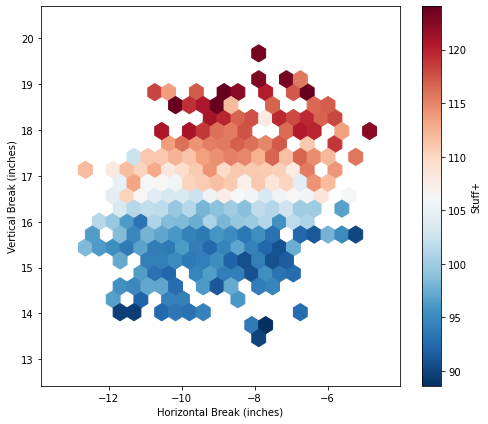

In [26]:
df_p = df_scored[df_scored['PlayerName'] == 'Jacob deGrom']
df_p = df_p[df_p.pitch_type == 'FF']

stuff_movement_heatmap(df_p, stuff_col="Stuff+_global")